<div align="center">

# 📊 Web Intelligence & NLP
## Final Insights & Business Intelligence

**Notebook 06 — End-to-End Findings, Recommendations & Dashboard-Ready Output**

![Data Analytics](https://images.unsplash.com/photo-1551288049-bebda4e38f71?auto=format&fit=crop&w=1600&q=80)

</div>

---

### Project
**Web Intelligence and NLP-Based Sentiment Analytics**

### Notebook Objective

This is the final analytical notebook. It brings together the outputs generated across the complete NLP pipeline and converts model results into a **clear, evidence-based analytical story**.

We will combine:

- dataset overview
- sentiment distribution
- sentiment scores
- author-level analysis
- keyword intelligence
- n-gram intelligence
- topic modeling
- topic × sentiment analysis
- model agreement/error indicators
- representative examples
- final insights
- limitations
- recommendations
- dashboard-ready dataset

> **Important:** The current source, Quotes to Scrape, is a small practice corpus and does not contain human sentiment labels, product ratings, or business transaction data. Therefore, this notebook demonstrates a professional analytical workflow, but its findings should not be presented as real customer-business intelligence.


# 🧭 Complete Project Position

```text
01 Web Scraping
      ↓
02 Data Cleaning & EDA
      ↓
03 NLP Preprocessing
      ↓
04 Sentiment Analysis
      ↓
05 Keyword & Topic Analysis
      ↓
06 Final Insights  ← YOU ARE HERE
      ↓
Streamlit Dashboard
      ↓
Deployment
```

### Final Notebook Principle

The goal is not simply to show charts.

The goal is:

```text
Data
 ↓
Evidence
 ↓
Pattern
 ↓
Interpretation
 ↓
Insight
 ↓
Recommendation
```


# 1. Setup and Imports

We import only the libraries needed for final aggregation, validation, visualization, and export.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 150)

print("Libraries imported successfully.")

Libraries imported successfully.


# 2. Project Paths

This notebook reads the reusable outputs produced by Notebooks 02–05 and creates final reporting artifacts.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
FINAL_DATA_DIR = DATA_DIR / "final"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
REPORTS_DIR = OUTPUTS_DIR / "reports"

for directory in [
    FINAL_DATA_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    REPORTS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

CLEANED_FILE = PROCESSED_DATA_DIR / "cleaned_quotes.csv"
NLP_FILE = FINAL_DATA_DIR / "nlp_ready_quotes.csv"
SENTIMENT_FILE = FINAL_DATA_DIR / "sentiment_analysis_results.csv"
KEYWORD_FILE = FINAL_DATA_DIR / "keyword_analysis.csv"
TOPIC_FILE = FINAL_DATA_DIR / "topic_analysis.csv"
TOPIC_SUMMARY_FILE = FINAL_DATA_DIR / "topic_summary.csv"

print("Project root:", PROJECT_ROOT)

Project root: D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP


# 3. Load Project Outputs

We use the final outputs from previous notebooks rather than rebuilding the entire pipeline.

Expected files:

```text
02 → cleaned_quotes.csv
03 → nlp_ready_quotes.csv
04 → sentiment_analysis_results.csv
05 → keyword_analysis.csv
05 → topic_analysis.csv
05 → topic_summary.csv
```

This separation makes the project easier to reproduce and maintain.

In [3]:
def load_csv(path, required=True):
    if not path.exists():
        if required:
            raise FileNotFoundError(f"Required file not found: {path}")
        print(f"Optional file not found: {path}")
        return None

    data = pd.read_csv(path)
    print(f"Loaded {path.name}: {data.shape}")
    return data

cleaned_df = load_csv(CLEANED_FILE, required=False)
nlp_df = load_csv(NLP_FILE, required=True)
sentiment_df = load_csv(SENTIMENT_FILE, required=True)
keyword_df = load_csv(KEYWORD_FILE, required=True)
topic_df = load_csv(TOPIC_FILE, required=True)
topic_summary_df = load_csv(TOPIC_SUMMARY_FILE, required=True)

Loaded cleaned_quotes.csv: (100, 6)
Loaded nlp_ready_quotes.csv: (100, 19)
Loaded sentiment_analysis_results.csv: (100, 10)
Loaded keyword_analysis.csv: (1474, 3)
Loaded topic_analysis.csv: (100, 12)
Loaded topic_summary.csv: (3, 5)


# 4. Build the Final Integrated Dataset

The integrated dataset becomes the central table for final analysis.

We join topic information with sentiment results using `quote_id` when available.

In [4]:
# Start with sentiment results because Notebook 04 contains the main final prediction fields.
final_df = sentiment_df.copy()

if "quote_id" in final_df.columns and "quote_id" in topic_df.columns:
    topic_columns = [
        col for col in [
            "quote_id",
            "lda_dominant_topic",
            "lda_topic_score",
            "nmf_dominant_topic",
            "nmf_topic_score"
        ]
        if col in topic_df.columns
    ]

    topic_lookup = topic_df[topic_columns].drop_duplicates("quote_id")

    final_df = final_df.merge(
        topic_lookup,
        on="quote_id",
        how="left",
        suffixes=("", "_topic")
    )

print("Integrated dataset shape:", final_df.shape)
display(final_df.head())

Integrated dataset shape: (100, 14)


,quote_id,original_text,processed_text,author,tags,source_url,compound_score,sentiment,predicted_sentiment,prediction_score,lda_dominant_topic,lda_topic_score,nmf_dominant_topic,nmf_topic_score
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,0.2500,Positive,Positive,0.625670,3,0.957324,3,0.062148
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,0.6369,Positive,Negative,-0.155010,2,0.942403,1,0.023429
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,-0.7306,Negative,Negative,0.545688,2,0.968235,2,0.424442
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,0.6705,Positive,Positive,0.625305,2,0.961843,1,0.088947
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,-0.2143,Negative,Negative,0.578668,3,0.962617,1,0.016669


# 5. Final Data Validation

Before generating insights, we verify the structure of the integrated dataset.

Key checks:

- row count
- column availability
- missing values
- duplicate IDs
- sentiment categories
- topic assignments

In [5]:
print("Shape:", final_df.shape)
print("\nColumns:")
print(final_df.columns.tolist())

if "quote_id" in final_df.columns:
    print("\nDuplicate quote IDs:", final_df["quote_id"].duplicated().sum())

print("\nMissing values:")
display(
    final_df.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
    .head(15)
)

if "sentiment" in final_df.columns:
    print("\nSentiment values:")
    print(final_df["sentiment"].value_counts(dropna=False))

if "lda_dominant_topic" in final_df.columns:
    print("\nTopic values:")
    print(final_df["lda_dominant_topic"].value_counts(dropna=False).sort_index())

Shape: (100, 14)

Columns:
['quote_id', 'original_text', 'processed_text', 'author', 'tags', 'source_url', 'compound_score', 'sentiment', 'predicted_sentiment', 'prediction_score', 'lda_dominant_topic', 'lda_topic_score', 'nmf_dominant_topic', 'nmf_topic_score']

Duplicate quote IDs: 0

Missing values:


,missing_count
tags,3
quote_id,0
original_text,0
processed_text,0
author,0
source_url,0
compound_score,0
sentiment,0
predicted_sentiment,0
prediction_score,0



Sentiment values:
sentiment
Positive    47
Negative    32
Neutral     21
Name: count, dtype: int64

Topic values:
lda_dominant_topic
1    27
2    39
3    34
Name: count, dtype: int64


# 6. Executive Dataset Overview

We establish the high-level scale of the analysis before looking at detailed patterns.

In [6]:
overview = {
    "Total Documents": len(final_df),
    "Unique Authors": final_df["author"].nunique() if "author" in final_df.columns else np.nan,
    "Unique Tags": (
        final_df["tags"]
        .fillna("")
        .str.split(", ")
        .explode()
        .replace("", np.nan)
        .nunique()
        if "tags" in final_df.columns else np.nan
    ),
    "Positive Documents": (
        (final_df["sentiment"] == "Positive").sum()
        if "sentiment" in final_df.columns else np.nan
    ),
    "Neutral Documents": (
        (final_df["sentiment"] == "Neutral").sum()
        if "sentiment" in final_df.columns else np.nan
    ),
    "Negative Documents": (
        (final_df["sentiment"] == "Negative").sum()
        if "sentiment" in final_df.columns else np.nan
    )
}

overview_df = pd.DataFrame(
    list(overview.items()),
    columns=["Metric", "Value"]
)

display(overview_df)

,Metric,Value
0,Total Documents,100
1,Unique Authors,50
2,Unique Tags,137
3,Positive Documents,47
4,Neutral Documents,21
5,Negative Documents,32


# 7. Overall Sentiment Analysis

We summarize the final sentiment labels generated in Notebook 04.

Remember:

> These sentiment labels originate from a weak-labeling pipeline based on VADER because the source dataset does not provide human-annotated sentiment ground truth.

In [7]:
if "sentiment" in final_df.columns:
    sentiment_summary = (
        final_df["sentiment"]
        .value_counts()
        .rename_axis("sentiment")
        .reset_index(name="document_count")
    )

    sentiment_summary["percentage"] = (
        sentiment_summary["document_count"] / len(final_df) * 100
    ).round(2)

    display(sentiment_summary)
else:
    sentiment_summary = pd.DataFrame()

,sentiment,document_count,percentage
0,Positive,47,47.0
1,Negative,32,32.0
2,Neutral,21,21.0


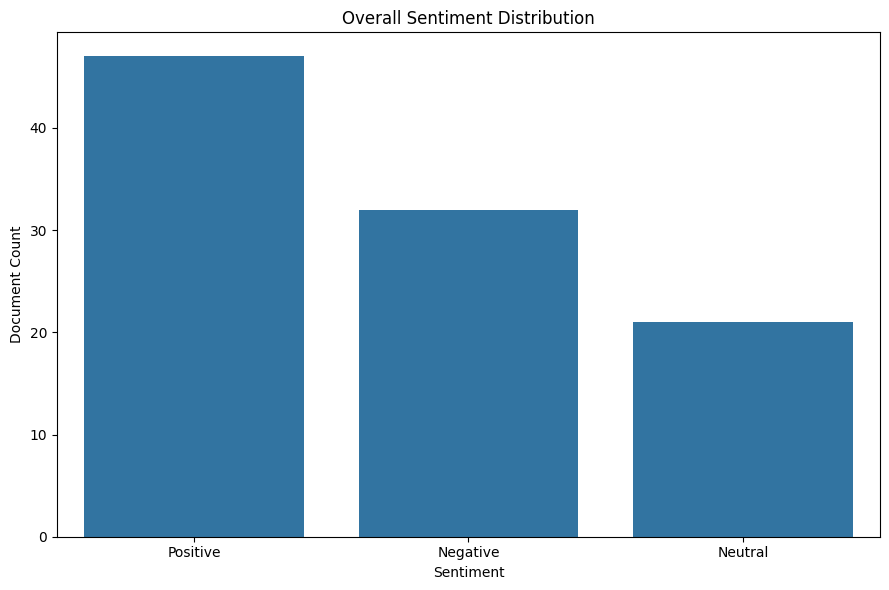

In [8]:
if not sentiment_summary.empty:
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=sentiment_summary,
        x="sentiment",
        y="document_count"
    )
    plt.title("Overall Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Document Count")
    plt.tight_layout()
    plt.show()

### Analytical Observation

When interpreting the sentiment distribution, look for:

- dominant sentiment class
- class imbalance
- unusually small minority classes
- whether the dataset is sufficiently balanced for downstream modeling

Do not automatically interpret a dominant positive class as proof that the underlying population is genuinely positive.

# 8. Sentiment Score Analysis

If VADER compound scores are available, we inspect their numerical distribution.

The compound score ranges approximately from:

```text
-1  → strongly negative
 0  → neutral / mixed
+1  → strongly positive
```

,compound_score
count,100.000000
mean,0.161957
std,0.511925
min,-0.922900
25%,-0.232225
50%,0.000000
75%,0.636900
max,0.979700


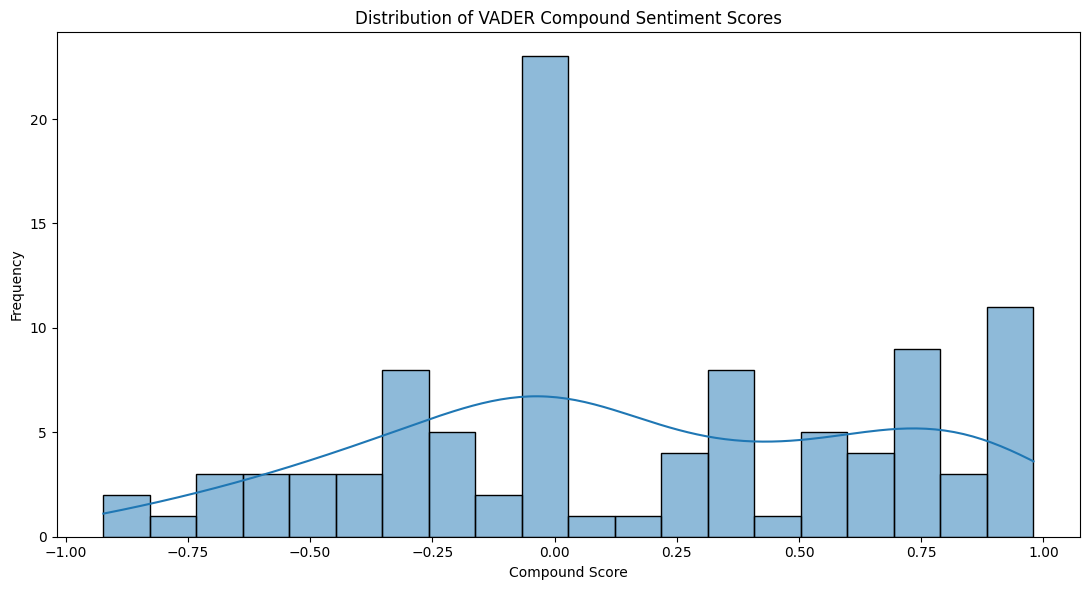

In [9]:
if "compound_score" in final_df.columns:
    score_summary = final_df["compound_score"].describe().to_frame("compound_score")
    display(score_summary)

    plt.figure(figsize=(11, 6))
    sns.histplot(
        final_df["compound_score"].dropna(),
        bins=20,
        kde=True
    )
    plt.title("Distribution of VADER Compound Sentiment Scores")
    plt.xlabel("Compound Score")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 9. Author-Level Sentiment Analysis

The source contains author information, so we can examine whether sentiment composition differs across authors.

This is an exploratory relationship, not a claim about the authors' personal beliefs.

In [10]:
if {"author", "sentiment"}.issubset(final_df.columns):
    author_sentiment = pd.crosstab(
        final_df["author"],
        final_df["sentiment"],
        normalize="index"
    ).mul(100).round(2)

    display(author_sentiment.head(20))

    author_counts = (
        final_df["author"]
        .value_counts()
        .rename_axis("author")
        .reset_index(name="document_count")
    )

    display(author_counts.head(15))

sentiment,Negative,Neutral,Positive
author,,,
Albert Einstein,20.00,30.00,50.00
Alexandre Dumas fils,100.00,0.00,0.00
Alfred Tennyson,0.00,100.00,0.00
Allen Saunders,0.00,100.00,0.00
André Gide,0.00,0.00,100.00
Ayn Rand,100.00,0.00,0.00
Bob Marley,66.67,0.00,33.33
C.S. Lewis,0.00,60.00,40.00
Charles Bukowski,100.00,0.00,0.00


,author,document_count
0,Albert Einstein,10
1,J.K. Rowling,9
2,Marilyn Monroe,7
3,Dr. Seuss,6
4,Mark Twain,6
5,Jane Austen,5
6,C.S. Lewis,5
7,Bob Marley,3
8,Eleanor Roosevelt,2
9,Ralph Waldo Emerson,2


# 10. Keyword Intelligence

The keyword analysis from Notebook 05 provides two complementary perspectives:

### Frequency
What appears often?

### TF-IDF
What is comparatively distinctive?

We inspect the strongest keywords first.

In [11]:
if not keyword_df.empty:
    display(keyword_df.head(30))

,keyword,mean_tfidf,frequency
0,love,0.025317,24
1,life,0.022377,17
2,one,0.022093,17
3,never,0.019589,13
4,book,0.017744,10
5,thing,0.016790,10
6,think,0.015165,14
7,know,0.015152,8
8,like,0.014778,9
9,people,0.014629,7


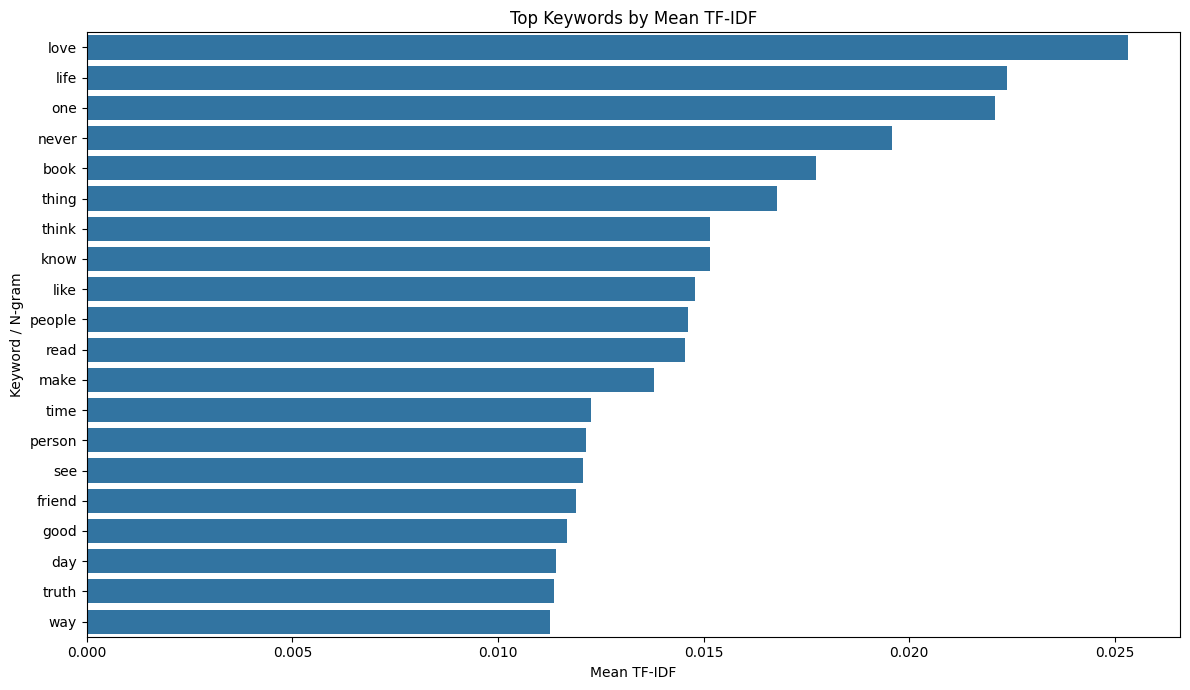

In [12]:
if {"keyword", "mean_tfidf"}.issubset(keyword_df.columns):
    top_keywords = keyword_df.head(20).copy()

    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=top_keywords,
        x="mean_tfidf",
        y="keyword"
    )
    plt.title("Top Keywords by Mean TF-IDF")
    plt.xlabel("Mean TF-IDF")
    plt.ylabel("Keyword / N-gram")
    plt.tight_layout()
    plt.show()

# 11. Top N-Grams

N-grams provide phrase-level context that single keywords cannot provide.

For example:

```text
"machine" + "learning"
```

can become:

```text
"machine learning"
```

This can make thematic interpretation more meaningful.

In [13]:
top_bigrams_file = TABLES_DIR / "top_bigrams.csv"
top_trigrams_file = TABLES_DIR / "top_trigrams.csv"

bigrams_df = load_csv(top_bigrams_file, required=False)
trigrams_df = load_csv(top_trigrams_file, required=False)

if bigrams_df is not None:
    print("Top Bigrams")
    display(bigrams_df.head(20))

if trigrams_df is not None:
    print("Top Trigrams")
    display(trigrams_df.head(20))

Loaded top_bigrams.csv: (20, 2)
Loaded top_trigrams.csv: (20, 2)
Top Bigrams


,ngram,frequency
0,happens drink,3
1,fairy tale,3
2,indifference opposite,3
3,intelligent read,2
4,every day,2
5,going mess,2
6,become man,2
7,best friend,2
8,everyone else,2
9,die time,2


Top Trigrams


,ngram,frequency
0,intelligent read fairy,2
1,read fairy tale,2
2,youll never find,2
3,youre going mess,2
4,world truth putting,1
5,admit human making,1
6,youre gon na,1
7,actually pretty much,1
8,ahead come behind,1
9,airless change broken,1


# 12. Topic Intelligence

We now interpret the topics discovered in Notebook 05.

The topic summary contains:

- topic ID
- document count
- document percentage
- average topic score
- representative top words

These are **model-discovered themes**, not predefined business categories.

In [14]:
display(topic_summary_df)

,topic,document_count,avg_topic_score,document_percentage,top_words
0,1,27,0.953865,27.0,"make, friend, go, dont, keep, going, may, never, remember, good"
1,2,39,0.952760,39.0,"love, think, life, way, read, know, live, thing, one, want"
2,3,34,0.934678,34.0,"one, truth, opposite, indifference, life, never, love, book, day, world"


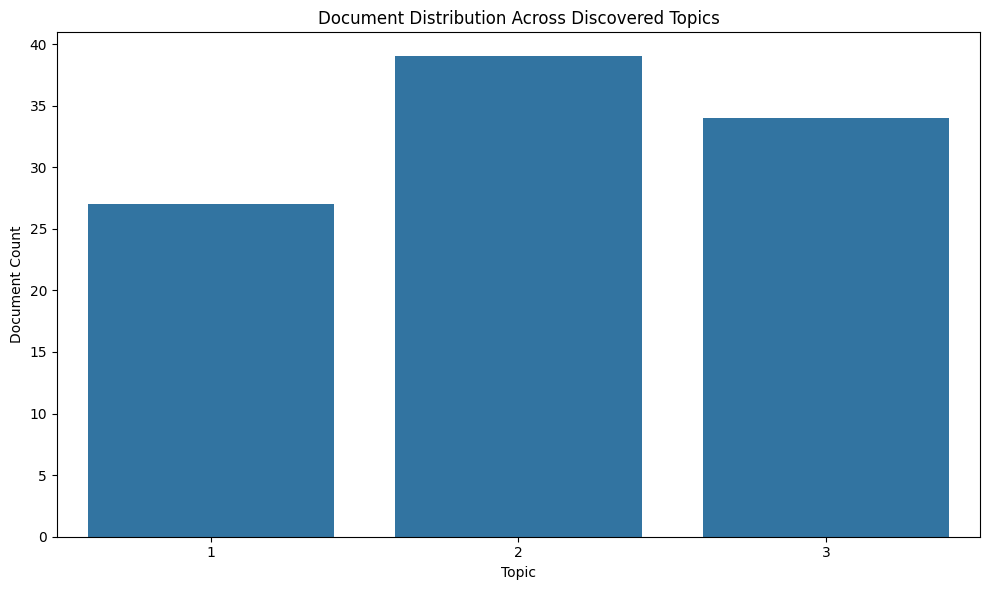

In [15]:
if {"topic", "document_count"}.issubset(topic_summary_df.columns):
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=topic_summary_df,
        x="topic",
        y="document_count"
    )
    plt.title("Document Distribution Across Discovered Topics")
    plt.xlabel("Topic")
    plt.ylabel("Document Count")
    plt.tight_layout()
    plt.show()

# 13. Topic × Sentiment Intelligence

This is the key synthesis step:

```text
What are people talking about?
             +
How is that topic expressed?
             ↓
Topic-level sentiment profile
```

For a real review dataset, this could become a powerful issue-detection framework.

In [16]:
if {"lda_dominant_topic", "sentiment"}.issubset(final_df.columns):
    topic_sentiment_counts = pd.crosstab(
        final_df["lda_dominant_topic"],
        final_df["sentiment"]
    )

    topic_sentiment_pct = pd.crosstab(
        final_df["lda_dominant_topic"],
        final_df["sentiment"],
        normalize="index"
    ).mul(100).round(2)

    print("Topic × Sentiment Counts")
    display(topic_sentiment_counts)

    print("Topic × Sentiment Percentages")
    display(topic_sentiment_pct)
else:
    topic_sentiment_counts = pd.DataFrame()
    topic_sentiment_pct = pd.DataFrame()
    print("Required topic/sentiment columns are unavailable.")

Topic × Sentiment Counts


sentiment,Negative,Neutral,Positive
lda_dominant_topic,,,
1,7,6,14
2,12,7,20
3,13,8,13


Topic × Sentiment Percentages


sentiment,Negative,Neutral,Positive
lda_dominant_topic,,,
1,25.93,22.22,51.85
2,30.77,17.95,51.28
3,38.24,23.53,38.24


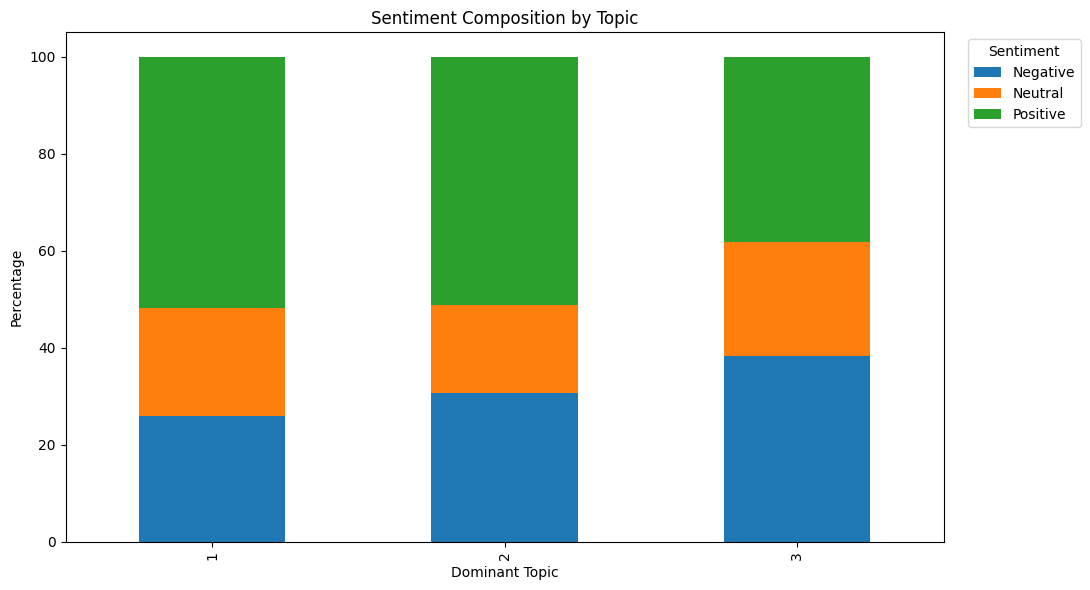

In [17]:
if not topic_sentiment_pct.empty:
    topic_sentiment_pct.plot(
        kind="bar",
        stacked=True,
        figsize=(11, 6)
    )
    plt.title("Sentiment Composition by Topic")
    plt.xlabel("Dominant Topic")
    plt.ylabel("Percentage")
    plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

# 14. Identify Potentially Important Themes

For a production review dataset, a topic can be prioritized using a combination of:

```text
Topic Size
    +
Negative Sentiment Rate
    +
Topic Confidence
```

This creates a simple analytical prioritization framework.

For the current practice dataset, we demonstrate the calculation but avoid presenting it as operational business risk.

In [18]:
if {"lda_dominant_topic", "sentiment", "lda_topic_score"}.issubset(final_df.columns):
    topic_priority = (
        final_df
        .groupby("lda_dominant_topic")
        .agg(
            document_count=("processed_text", "count"),
            avg_topic_score=("lda_topic_score", "mean"),
            negative_rate=("sentiment", lambda x: (x == "Negative").mean() * 100),
            positive_rate=("sentiment", lambda x: (x == "Positive").mean() * 100)
        )
        .reset_index()
        .rename(columns={"lda_dominant_topic": "topic"})
    )

    topic_priority["negative_rate"] = topic_priority["negative_rate"].round(2)
    topic_priority["positive_rate"] = topic_priority["positive_rate"].round(2)
    topic_priority["avg_topic_score"] = topic_priority["avg_topic_score"].round(4)

    display(topic_priority.sort_values("negative_rate", ascending=False))

,topic,document_count,avg_topic_score,negative_rate,positive_rate
2,3,34,0.9347,38.24,38.24
1,2,39,0.9528,30.77,51.28
0,1,27,0.9539,25.93,51.85


# 15. Model Agreement / Prediction Review

Notebook 04 compared machine-learning predictions with weak VADER labels.

If both fields are available, we quantify agreement.

This should be described as **agreement with weak labels**, not true model accuracy against human ground truth.

In [19]:
if {"sentiment", "predicted_sentiment"}.issubset(final_df.columns):
    agreement_rate = (
        final_df["sentiment"] == final_df["predicted_sentiment"]
    ).mean() * 100

    print(f"Prediction agreement with weak labels: {agreement_rate:.2f}%")

    disagreement_df = final_df[
        final_df["sentiment"] != final_df["predicted_sentiment"]
    ].copy()

    print("Number of disagreements:", len(disagreement_df))

    display(
        disagreement_df[
            [
                col for col in [
                    "original_text",
                    "processed_text",
                    "sentiment",
                    "predicted_sentiment",
                    "compound_score",
                    "prediction_score"
                ]
                if col in disagreement_df.columns
            ]
        ].head(15)
    )

Prediction agreement with weak labels: 90.00%
Number of disagreements: 10


,original_text,processed_text,sentiment,predicted_sentiment,compound_score,prediction_score
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,Positive,Negative,0.6369,-0.155010
16,"“The opposite of love is not hate, it's indifference. The opposite of art is not ugliness, it's indifference. The opposite of faith is not heresy,...",opposite love hate indifference opposite art ugliness indifference opposite faith heresy indifference opposite life death indifference,Negative,Positive,-0.7269,0.037006
21,“For every minute you are angry you lose sixty seconds of happiness.”,every minute angry lose sixty second happiness,Negative,Positive,-0.3400,0.093264
26,"“If you want your children to be intelligent, read them fairy tales. If you want them to be more intelligent, read them more fairy tales.”",want child intelligent read fairy tale want intelligent read fairy tale,Positive,Neutral,0.7650,-0.089142
32,"“The truth is, everyone is going to hurt you. You just got to find the ones worth suffering for.”",truth everyone going hurt got find one worth suffering,Negative,Positive,-0.5106,-0.025984
51,“Do one thing every day that scares you.”,one thing every day scare,Negative,Positive,-0.4939,-0.019511
64,“Not all those who wander are lost.”,wander lost,Negative,Positive,-0.3182,-0.089677
68,“I have never let my schooling interfere with my education.”,never let schooling interfere education,Neutral,Negative,0.0000,-0.178402
70,“If I had a flower for every time I thought of you...I could walk through my garden forever.”,flower every time thought youi could walk garden forever,Neutral,Positive,0.0000,-0.071972
95,“You never really understand a person until you consider things from his point of view... Until you climb inside of his skin and walk around in it.”,never really understand person consider thing point view climb inside skin walk around,Neutral,Positive,0.0000,-0.148352


# 16. Representative Examples

Quantitative metrics should be supported by qualitative inspection.

We select representative examples from each sentiment class when available.

In [20]:
if "sentiment" in final_df.columns:
    for label in ["Positive", "Neutral", "Negative"]:
        subset = final_df[final_df["sentiment"] == label]

        if len(subset) == 0:
            continue

        print("=" * 90)
        print(f"{label.upper()} EXAMPLES")
        print("=" * 90)

        display(
            subset[
                [
                    col for col in [
                        "original_text",
                        "processed_text",
                        "compound_score",
                        "predicted_sentiment"
                    ]
                    if col in subset.columns
                ]
            ].head(5)
        )

POSITIVE EXAMPLES


,original_text,processed_text,compound_score,predicted_sentiment
0,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,0.2500,Positive
1,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,0.6369,Negative
3,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,0.6705,Positive
5,“Try not to become a man of success. Rather become a man of value.”,try become man success rather become man value,0.7269,Positive
6,“It is better to be hated for what you are than to be loved for what you are not.”,better hated loved,0.3818,Positive


NEUTRAL EXAMPLES


,original_text,processed_text,compound_score,predicted_sentiment
12,"“If you can't explain it to a six year old, you don't understand it yourself.”",cant explain six year old dont understand,0.0,Neutral
15,"“I may not have gone where I intended to go, but I think I have ended up where I needed to be.”",may gone intended go think ended needed,0.0,Neutral
19,“Life is what happens to us while we are making other plans.”,life happens u making plan,0.0,Neutral
23,“Anyone who thinks sitting in church can make you a Christian must also think that sitting in a garage can make you a car.”,anyone think sitting church make christian must also think sitting garage make car,0.0,Neutral
28,“Logic will get you from A to Z; imagination will get you everywhere.”,logic get z imagination get everywhere,0.0,Neutral


NEGATIVE EXAMPLES


,original_text,processed_text,compound_score,predicted_sentiment
2,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,-0.7306,Negative
4,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,-0.2143,Negative
7,"“I have not failed. I've just found 10,000 ways that won't work.”",failed ive found way wont work,-0.5106,Negative
8,“A woman is like a tea bag; you never know how strong it is until it's in hot water.”,woman like tea bag never know strong hot water,-0.0521,Negative
9,"“A day without sunshine is like, you know, night.”",day without sunshine like know night,-0.5773,Negative


# 17. Automated Insight Candidates

We can generate objective candidate statements from the computed metrics.

These are **starting points for human interpretation**, not automatically validated business conclusions.

In [21]:
insight_candidates = []

if not sentiment_summary.empty:
    dominant_sentiment_row = sentiment_summary.iloc[0]
    insight_candidates.append(
        f"The most frequent sentiment class is {dominant_sentiment_row['sentiment']} "
        f"with {dominant_sentiment_row['percentage']:.2f}% of documents."
    )

if not keyword_df.empty and "keyword" in keyword_df.columns:
    top_keyword = keyword_df.iloc[0]["keyword"]
    insight_candidates.append(
        f"The highest-ranked TF-IDF keyword/phrase is '{top_keyword}'."
    )

if not topic_summary_df.empty and {"topic", "document_count"}.issubset(topic_summary_df.columns):
    largest_topic = topic_summary_df.loc[
        topic_summary_df["document_count"].idxmax()
    ]
    insight_candidates.append(
        f"Topic {int(largest_topic['topic'])} contains the largest number of documents "
        f"({int(largest_topic['document_count'])})."
    )

if not topic_priority.empty:
    highest_negative_topic = topic_priority.loc[
        topic_priority["negative_rate"].idxmax()
    ]
    insight_candidates.append(
        f"Topic {int(highest_negative_topic['topic'])} has the highest observed "
        f"negative-sentiment rate ({highest_negative_topic['negative_rate']:.2f}%)."
    )

for i, insight in enumerate(insight_candidates, start=1):
    print(f"{i}. {insight}")

1. The most frequent sentiment class is Positive with 47.00% of documents.
2. The highest-ranked TF-IDF keyword/phrase is 'love'.
3. Topic 2 contains the largest number of documents (39).
4. Topic 3 has the highest observed negative-sentiment rate (38.24%).


# 18. Business / Analytical Recommendations Framework

Because the current dataset is a quote corpus, we should **not invent customer actions**.

Instead, we define the recommendation framework that would be used when this pipeline is connected to real review, feedback, support, or social-media data.

### If a topic has high negative sentiment

Recommended investigation:

```text
Identify topic
    ↓
Inspect representative documents
    ↓
Validate with domain expert
    ↓
Find root cause
    ↓
Prioritize intervention
```

### If a topic has high positive sentiment

Recommended action:

```text
Identify strength
    ↓
Understand why users value it
    ↓
Protect the experience
    ↓
Consider using the strength in messaging
```

### If a topic is large but mixed

Recommended action:

```text
Segment the topic
    ↓
Inspect positive vs negative examples
    ↓
Identify specific sub-themes
    ↓
Run deeper analysis
```


# 19. Project Limitations

A professional project must clearly communicate limitations.

### 1. Small Dataset

Quotes to Scrape is a small educational scraping corpus. Topic modeling and ML performance can be unstable with limited documents.

### 2. No Human Sentiment Labels

The sentiment labels are weak/pseudo labels derived from VADER.

Therefore:

```text
Model metric ≠ true real-world accuracy
```

### 3. No Ratings

The current source does not provide meaningful product ratings, so rating-vs-sentiment analysis is not applicable.

### 4. No Reliable Business Time Series

There is no business event timeline suitable for operational trend analysis.

### 5. Topic Interpretation

LDA/NMF topics require human interpretation. The model does not inherently know business concepts.

### 6. Domain Mismatch

The pipeline becomes much more valuable when applied to:

- customer reviews
- support tickets
- survey responses
- social-media feedback
- app reviews
- product feedback
- complaint data

### 7. Weak-Label Bias

VADER can misinterpret context, sarcasm, domain-specific language, and nuanced sentiment.

---

## Production Improvement

For a production-grade version, replace weak labels with:

```text
Human-Labeled Dataset
        ↓
Train / Validation / Test
        ↓
Cross-Validation
        ↓
Model Selection
        ↓
Calibration
        ↓
External Validation
```

Possible advanced models:

```text
BERT
RoBERTa
DistilBERT
DeBERTa
```


# 20. Build Dashboard-Ready Dataset

The dashboard should not need to understand the entire notebook pipeline.

We therefore create one clean, reusable dataset containing the most useful analytical fields.

In [22]:
dashboard_columns = [
    "quote_id",
    "original_text",
    "processed_text",
    "author",
    "tags",
    "source_url",
    "compound_score",
    "sentiment",
    "predicted_sentiment",
    "prediction_score",
    "lda_dominant_topic",
    "lda_topic_score",
    "nmf_dominant_topic",
    "nmf_topic_score"
]

dashboard_df = final_df[
    [col for col in dashboard_columns if col in final_df.columns]
].copy()

dashboard_output = FINAL_DATA_DIR / "nlp_final_dataset.csv"
dashboard_df.to_csv(dashboard_output, index=False)

print("Dashboard-ready dataset saved to:")
print(dashboard_output)
print("Shape:", dashboard_df.shape)

display(dashboard_df.head())

Dashboard-ready dataset saved to:
D:\Data-Science-Project\Data & Resources\Web-Intelligence-NLP\data\final\nlp_final_dataset.csv
Shape: (100, 14)


,quote_id,original_text,processed_text,author,tags,source_url,compound_score,sentiment,predicted_sentiment,prediction_score,lda_dominant_topic,lda_topic_score,nmf_dominant_topic,nmf_topic_score
0,1,“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”,world created process thinking changed without changing thinking,Albert Einstein,"change, deep-thoughts, thinking, world",https://quotes.toscrape.com/,0.2500,Positive,Positive,0.625670,3,0.957324,3,0.062148
1,2,"“It is our choices, Harry, that show what we truly are, far more than our abilities.”",choice harry show truly far ability,J.K. Rowling,"abilities, choices",https://quotes.toscrape.com/,0.6369,Positive,Negative,-0.155010,2,0.942403,1,0.023429
2,3,“There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”,two way live life one though nothing miracle though everything miracle,Albert Einstein,"inspirational, life, live, miracle, miracles",https://quotes.toscrape.com/,-0.7306,Negative,Negative,0.545688,2,0.968235,2,0.424442
3,4,"“The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”",person gentleman lady pleasure good novel must intolerably stupid,Jane Austen,"aliteracy, books, classic, humor",https://quotes.toscrape.com/,0.6705,Positive,Positive,0.625305,2,0.961843,1,0.088947
4,5,"“Imperfection is beauty, madness is genius and it's better to be absolutely ridiculous than absolutely boring.”",imperfection beauty madness genius better absolutely ridiculous absolutely boring,Marilyn Monroe,"be-yourself, inspirational",https://quotes.toscrape.com/,-0.2143,Negative,Negative,0.578668,3,0.962617,1,0.016669


# 21. Export Final Reporting Tables

We save compact tables that can be reused in presentations, reports, or the Streamlit dashboard.

In [23]:
# Overall sentiment
if not sentiment_summary.empty:
    sentiment_summary.to_csv(
        TABLES_DIR / "final_sentiment_summary.csv",
        index=False
    )

# Topic summary
topic_summary_df.to_csv(
    TABLES_DIR / "final_topic_summary.csv",
    index=False
)

# Topic × sentiment
if not topic_sentiment_pct.empty:
    topic_sentiment_pct.to_csv(
        TABLES_DIR / "topic_sentiment_percentage.csv"
    )

# Topic priority
if "topic_priority" in locals() and not topic_priority.empty:
    topic_priority.to_csv(
        TABLES_DIR / "topic_priority.csv",
        index=False
    )

# Top keywords
keyword_df.head(50).to_csv(
    TABLES_DIR / "final_top_keywords.csv",
    index=False
)

print("Final reporting tables exported.")

Final reporting tables exported.


# 22. Final Insight Report

We create a concise machine-generated report containing the measurable findings from this notebook.

The report deliberately separates **observed metrics** from **human interpretation**.

In [24]:
report_lines = []

report_lines.append("WEB INTELLIGENCE & NLP — FINAL INSIGHT REPORT")
report_lines.append("=" * 60)
report_lines.append("")

report_lines.append("DATASET OVERVIEW")
report_lines.append("-" * 60)
report_lines.append(f"Total documents: {len(final_df)}")

if "author" in final_df.columns:
    report_lines.append(f"Unique authors: {final_df['author'].nunique()}")

if "sentiment" in final_df.columns:
    sentiment_counts = final_df["sentiment"].value_counts()
    for label in ["Positive", "Neutral", "Negative"]:
        if label in sentiment_counts:
            pct = sentiment_counts[label] / len(final_df) * 100
            report_lines.append(
                f"{label} documents: {sentiment_counts[label]} ({pct:.2f}%)"
            )

report_lines.append("")
report_lines.append("TOP KEYWORD")
report_lines.append("-" * 60)

if not keyword_df.empty:
    report_lines.append(
        f"Top TF-IDF keyword/phrase: {keyword_df.iloc[0]['keyword']}"
    )

report_lines.append("")
report_lines.append("TOPIC OVERVIEW")
report_lines.append("-" * 60)

if not topic_summary_df.empty:
    for _, row in topic_summary_df.iterrows():
        words = row.get("top_words", "")
        report_lines.append(
            f"Topic {int(row['topic'])}: "
            f"{int(row['document_count'])} documents; "
            f"top words = {words}"
        )

report_lines.append("")
report_lines.append("LIMITATION")
report_lines.append("-" * 60)
report_lines.append(
    "Sentiment labels are weak/pseudo labels based on VADER because the "
    "source corpus does not contain human-annotated sentiment ground truth."
)

report_text = "\n".join(report_lines)

report_path = REPORTS_DIR / "final_insight_report.txt"
report_path.write_text(report_text, encoding="utf-8")

print(report_text)
print("\nReport saved to:", report_path)

WEB INTELLIGENCE & NLP — FINAL INSIGHT REPORT

DATASET OVERVIEW
------------------------------------------------------------
Total documents: 100
Unique authors: 50
Positive documents: 47 (47.00%)
Neutral documents: 21 (21.00%)
Negative documents: 32 (32.00%)

TOP KEYWORD
------------------------------------------------------------
Top TF-IDF keyword/phrase: love

TOPIC OVERVIEW
------------------------------------------------------------
Topic 1: 27 documents; top words = make, friend, go, dont, keep, going, may, never, remember, good
Topic 2: 39 documents; top words = love, think, life, way, read, know, live, thing, one, want
Topic 3: 34 documents; top words = one, truth, opposite, indifference, life, never, love, book, day, world

LIMITATION
------------------------------------------------------------
Sentiment labels are weak/pseudo labels based on VADER because the source corpus does not contain human-annotated sentiment ground truth.

Report saved to: D:\Data-Science-Project\Data

# 23. Final Quality Checks

The project is considered ready for dashboard development only after validating the final artifact.

In [25]:
assert dashboard_output.exists()
assert report_path.exists()

dashboard_reload = pd.read_csv(dashboard_output)

assert len(dashboard_reload) == len(final_df)

if "quote_id" in dashboard_reload.columns:
    assert dashboard_reload["quote_id"].duplicated().sum() == 0

print("Dashboard dataset:", dashboard_reload.shape)
print("Report exists:", report_path.exists())
print("All final quality checks passed.")

Dashboard dataset: (100, 14)
Report exists: True
All final quality checks passed.


# 24. Final Project Outcome

The complete analytical pipeline now produces:

```text
🌐 Web Data
    ↓
🕷️ Scraped Dataset
    ↓
🧹 Clean Dataset
    ↓
📝 NLP-Ready Text
    ↓
❤️ Sentiment Intelligence
    ↓
🔑 Keyword Intelligence
    ↓
🧠 Topic Intelligence
    ↓
📊 Final Insights
    ↓
🚀 Dashboard-Ready Dataset
```

### Final Dataset

```text
data/final/nlp_final_dataset.csv
```

### Reporting Outputs

```text
outputs/
├── figures/
├── tables/
│   ├── final_sentiment_summary.csv
│   ├── final_topic_summary.csv
│   ├── topic_sentiment_percentage.csv
│   ├── topic_priority.csv
│   └── final_top_keywords.csv
│
└── reports/
    └── final_insight_report.txt
```


# 25. 🚀 Next Phase — Streamlit Dashboard

The six-notebook analytical pipeline is now complete.

The next layer is the interactive application:

```text
data/final/nlp_final_dataset.csv
              ↓
        Streamlit App
              ↓
┌───────────────────────────────┐
│ KPI Cards                     │
│ Sentiment Distribution        │
│ Keyword Analysis              │
│ Topic Distribution            │
│ Topic × Sentiment             │
│ Author Analysis               │
│ Quote Explorer                │
│ Filters                       │
└───────────────────────────────┘
              ↓
          Deployment
```

### Suggested Dashboard Pages

**1. Overview**
- total documents
- sentiment KPIs
- top keywords
- topic count

**2. Sentiment**
- positive / neutral / negative
- score distribution
- prediction comparison

**3. Topics**
- topic distribution
- topic words
- topic × sentiment

**4. Keywords**
- top TF-IDF keywords
- bigrams
- trigrams

**5. Explorer**
- searchable text
- author filter
- sentiment filter
- topic filter

---

# ✅ NOTEBOOK 06 COMPLETE

The notebook now serves as the **final analytical and reporting layer** of the project.

The next implementation target is:

```text
dashboard/app.py
```

where these saved outputs will be transformed into an interactive **Streamlit Web Intelligence & NLP Dashboard**.
